### Campaign for selling personal loans.

This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same time reduce the cost of the campaign.

The file Bank_Personal_Loan_Modelling.csvView in a new window  contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.

In [1]:
# import libraries
# pd, np
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
# sklearn support
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn import model_selection
from sklearn.metrics import roc_curve, auc
# sklearn classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
# Upload data
loan = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")
loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
ID                    5000 non-null int64
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


## 1.Read the column description and ensure you understand each attribute well

In [3]:
# ZIP Code cannot be used a categorical due to too many variations; 
# need feature engineering if to be used as valid independent variable
loan['ZIP Code'].value_counts().head()

94720    169
94305    127
95616    116
90095     71
93106     57
Name: ZIP Code, dtype: int64

In [4]:
# Generate numerical data overview
# Observations: Approx. 10% customers go for personal loans; Age, Experience and Income normally distributed; 
# Family, Education, Securities & CD Accounts, Online and CreditCard likely to be categorical
loan.describe()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


## 2.Study the data distribution in each attribute, share your findings. (5 points)

In [5]:
loan = loan.drop(['ID','ZIP Code'], axis=1)

In [6]:
# Target variable - Approx 10% positive labels
loan['Personal Loan'].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

In [7]:
# Categorical variables - Family, fairly distributed
loan['Family'].value_counts()

1    1472
2    1296
4    1222
3    1010
Name: Family, dtype: int64

In [8]:
# Evenly distributed amongst Target Labels
loan.groupby("Personal Loan")["Family"].agg("mean")

Personal Loan
0    2.373451
1    2.612500
Name: Family, dtype: float64

In [9]:
#loan = pd.read_csv("Bank_Personal_Loan_Modelling-1.csv")
# Create a set of dummy variables from the sex variable
loan_family = pd.get_dummies(loan['Family'])
# Join the dummy variables to the main dataframe
loan = pd.concat([loan, loan_family], axis=1)
loan = loan.drop(['Family'], axis=1)
# Rename columns
loan.columns.values[-1] = "Family_4"
loan.columns.values[-2] = "Family_3"
loan.columns.values[-3] = "Family_2"
loan.columns.values[-4] = "Family_1"
#loan.head().T

In [10]:
# Categorical variables - Education, fairly distributed
loan['Education'].value_counts()

1    2096
3    1501
2    1403
Name: Education, dtype: int64

In [11]:
# Evenly distributed amongst Target Labels
loan.groupby("Personal Loan")["Education"].agg("mean")

Personal Loan
0    1.843584
1    2.233333
Name: Education, dtype: float64

In [12]:
# Create a set of dummy variables from the sex variable
loan_education = pd.get_dummies(loan['Education'])
# Join the dummy variables to the main dataframe
loan = pd.concat([loan, loan_education], axis=1)
loan = loan.drop(['Education'], axis=1)
# Rename columns
loan.columns.values[-1] = "Education_3"
loan.columns.values[-2] = "Education_2"
loan.columns.values[-3] = "Education_1"
#loan.head().T

In [13]:
# Categorical variables - Securities Account, skewed
loan['Securities Account'].value_counts()

0    4478
1     522
Name: Securities Account, dtype: int64

In [14]:
# However, evenly distributed amongst Target Labels
loan.groupby("Personal Loan")["Securities Account"].agg("mean")

Personal Loan
0    0.102212
1    0.125000
Name: Securities Account, dtype: float64

In [15]:
# Categorical variables - Securities Account, skewed
loan['CD Account'].value_counts()

0    4698
1     302
Name: CD Account, dtype: int64

In [16]:
# Skewed towards Target Labels
loan.groupby("Personal Loan")["CD Account"].agg("mean")

Personal Loan
0    0.035841
1    0.291667
Name: CD Account, dtype: float64

In [17]:
# Categorical variables - Securities Account, fairly distributed
loan['Online'].value_counts()

1    2984
0    2016
Name: Online, dtype: int64

In [18]:
# Evenly distributed amongst Target Labels
loan.groupby("Personal Loan")["Online"].agg("mean")

Personal Loan
0    0.595796
1    0.606250
Name: Online, dtype: float64

In [19]:
# Categorical variables - Securities Account, skewed
loan['CreditCard'].value_counts()

0    3530
1    1470
Name: CreditCard, dtype: int64

In [20]:
# However, evenly distributed amongst Target Labels
loan.groupby("Personal Loan")["CreditCard"].agg("mean")

Personal Loan
0    0.293584
1    0.297917
Name: CreditCard, dtype: float64

In [21]:
# Rearrange loan.columns
loan = loan[['Age','Experience','Income','CCAvg','Mortgage','Securities Account','CD Account',
         'Online','CreditCard','Family_1','Family_2','Family_3','Family_4','Education_1','Education_2',
         'Education_3','Personal Loan']]
# Generate random samples for observation
random = loan.sample(n=5)
random.head().T

,656,4204,568,4689,796
Age,37.0,40.0,34.0,51.0,30.0
Experience,11.0,16.0,9.0,27.0,6.0
Income,81.0,61.0,41.0,43.0,82.0
CCAvg,2.8,2.1,0.1,1.1,2.5
Mortgage,145.0,0.0,161.0,164.0,0.0
Securities Account,0.0,0.0,0.0,0.0,0.0
CD Account,0.0,0.0,0.0,0.0,0.0
Online,0.0,0.0,1.0,1.0,0.0
CreditCard,0.0,0.0,1.0,1.0,0.0
Family_1,1.0,0.0,0.0,0.0,0.0


In [22]:
#loan.columns
loan = loan[['Age','Experience','Income','CCAvg','Mortgage','Securities Account','CD Account',
         'Online','CreditCard','Family_1','Family_2','Family_3','Family_4','Education_1','Education_2',
         'Education_3','Personal Loan']]

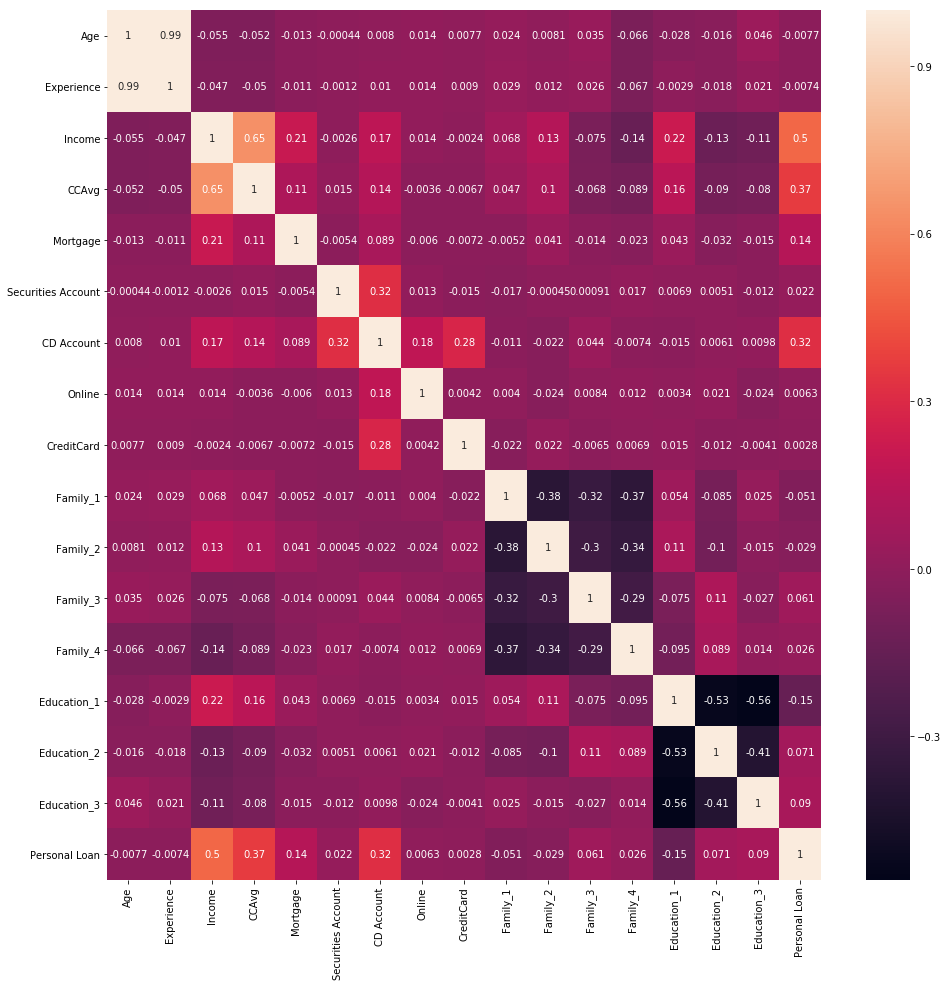

In [23]:
# correlation check
# Observations: Age-Experience, Income-CCAvg, Income-Personal Loan show strong correlations
corr = loan.corr()
plt.figure(figsize=(16,16)) 
sns.heatmap(corr, annot=True)

In [24]:
# Very few variables record linear correlation with target variable
corr_loan = corr.loc[:,["Personal Loan"]]
corr_loan = corr_loan.loc[corr_loan["Personal Loan"] != 1,:]
corr_loan = corr_loan.sort_values(by='Personal Loan', ascending=False)
corr_loan

,Personal Loan
Income,0.502462
CCAvg,0.366889
CD Account,0.316355
Mortgage,0.142095
Education_3,0.090212
Education_2,0.071491
Family_3,0.060942
Family_4,0.026364
Securities Account,0.021954
Online,0.006278


## 3.Get the target column distribution. Your comments (5 points)

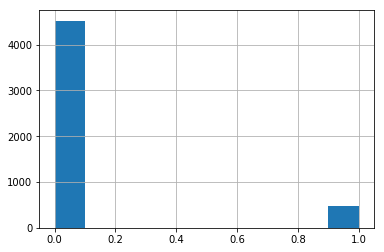

In [25]:
loan['Personal Loan'].hist()

In [26]:
loan['Personal Loan'].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

## 4.Split the data into training and test set in the ratio of 70:30 respectively ( 5 points)

In [27]:
X =  loan.drop(['Personal Loan'], axis=1)
y =  loan["Personal Loan"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## 5.Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)
## 6.Print the confusion matrix for all the above models (10 points)

In [28]:
# Logistic Regression
# For linear model, selecting variables with more than 0.1 or less than -0.1 (Slight or strong linear relations)
XL = loan.drop(['Personal Loan', 'Education_3', 'Education_2', 'Family_3', 'Family_4', 'Securities Account', 
                'Online', 'CreditCard', 'Experience', 'Age'], axis=1)
yL =  loan["Personal Loan"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
XL_train, XL_test, yL_train, yL_test = train_test_split(XL, yL, test_size=test_size, random_state=seed)
LogReg = LogisticRegression()
LogReg.fit(XL_train,yL_train)

parameter={'penalty':['l1','l2'], 'max_iter':[50,100,150]}
LogReg_GS=GridSearchCV(LogReg,parameter,cv=5)
LogReg_GS.fit(XL_train,yL_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(LogReg_GS.best_score_))
print("Best parameters: ", LogReg_GS.best_params_)

Best cross-validation score w/ kfold: 0.96
Best parameters:  {'max_iter': 50, 'penalty': 'l2'}


In [29]:
# Confusion matrix
LR_ypred = LogReg_GS.predict(XL_test)
cm=metrics.confusion_matrix(yL_test,LR_ypred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[1351   11]
 [  47   91]]


In [30]:
# KNN Classifier
KNN = KNeighborsClassifier()
KNN.fit(X_train,y_train)

parameter={'n_neighbors' : [5,10,15], 'weights' : ['uniform','distance'], 'p' : [1,2], 
           'algorithm' : ['auto','ball_tree','kd_tree'],'leaf_size' : [15,30,45], 'n_jobs' : [-1]}
KNN_GS=GridSearchCV(KNN,parameter,cv=5)
KNN_GS.fit(X_train,y_train)
print("Best cross-validation score w/ kfold: {:.2f}".format(KNN_GS.best_score_))
print("Best parameters: ", KNN_GS.best_params_)

Best cross-validation score w/ kfold: 0.92
Best parameters:  {'algorithm': 'auto', 'leaf_size': 15, 'n_jobs': -1, 'n_neighbors': 5, 'p': 1, 'weights': 'distance'}


In [31]:
# Confusion matrix
KNN_ypred = KNN_GS.predict(X_test)
cm=metrics.confusion_matrix(y_test,KNN_ypred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[1342   20]
 [  86   52]]


In [32]:
# GNB Classifier
GNB = GaussianNB()
GNB.fit(X_train,y_train)

GaussianNB(priors=None)

In [33]:
# Confusion matrix
GNB_ypred = GNB.predict(X_test)
cm=metrics.confusion_matrix(y_test,GNB_ypred)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[1253  109]
 [  54   84]]


## 7.Give your reasoning on which is the best model in this case and why it performs better? (10 points)

In [34]:
# function to evaluate each model in turn
def results_plot(metric, models, X, y, seed=7):
    results = []
    names = []
    scoring = metric # change evaluation metric as requred, example - accuracy, precision, f1, recall
    for name, model in models:
        kfold = model_selection.KFold(n_splits=5,random_state=seed)
        cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
        results.append(cv_results)
        names.append(name)
        msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
        #print(msg)
    # boxplot algorithm comparison
    fig = plt.figure()
    fig.suptitle('Algorithm Comparison')
    ax = fig.add_subplot(111)
    plt.boxplot(results)
    ax.set_xticklabels(names)
    plt.show()

In [35]:
# Compare models other than Logistic Regression for variance and bias error
models = []
models.append(('KNN', KNN_GS))
models.append(('GNB', GNB))

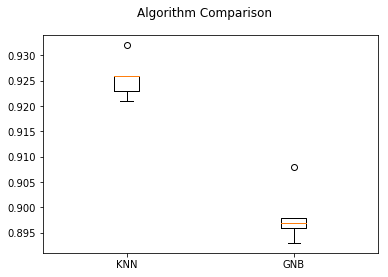

In [36]:
# K-fold accuracy test
results_plot('accuracy', models, X, y, seed=7)

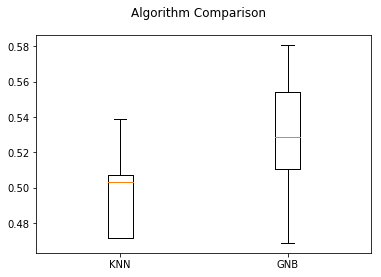

In [37]:
# K-fold f1_score test
results_plot('f1', models, X, y, seed=7)

In [38]:
# Compare Logistic Regression performance with others (accuracy)
kfold = model_selection.KFold(n_splits=5,random_state=seed)
cv_results = model_selection.cross_val_score(LogReg_GS, XL, yL, cv=kfold, scoring='accuracy')

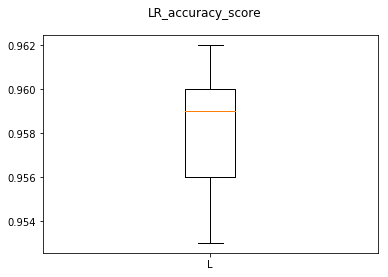

In [39]:
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('LR_accuracy_score')
ax = fig.add_subplot(111)
plt.boxplot(cv_results)
ax.set_xticklabels('LR')
plt.show()

In [40]:
# Compare Logistic Regression performance with others (f1-score)
kfold = model_selection.KFold(n_splits=5,random_state=seed)
cv_results = model_selection.cross_val_score(LogReg_GS, XL, yL, cv=kfold, scoring='f1')

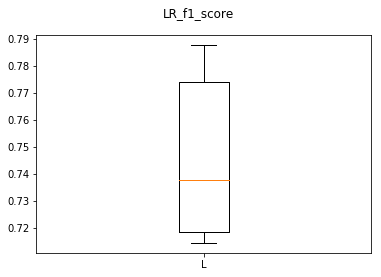

In [41]:
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('LR_f1_score')
ax = fig.add_subplot(111)
plt.boxplot(cv_results)
ax.set_xticklabels('LR')
plt.show()

## Logistic Regression performs the best for following reasons:
### 1. Records the highest accuracy and f1-score 
### 2. Variance error is comparably controlled if not better 

## Further performance evaluation for Logistic Regression model:

In [42]:
# Function to evaluate LR model performance
def ModelPerformanceAnalysis(selected_model, XL, yL, test_size = 0.3, seed = 7):
    XL_train, XL_test, yL_train, yL_test = train_test_split(XL, yL, test_size=test_size, random_state=seed)
    model = selected_model # Change model as required
    model.fit(XL_train, yL_train)
    ### Unoptimized probabilityL threshold based performance numbers
    # Train accuracyL numbers
    trainPreds = np.where(model.predict_proba(XL_train)[:,1] > 0.5, 1, 0)
    trainAccuracyL = accuracy_score(yL_train, trainPreds)
    trainRecall = recall_score(yL_train, trainPreds)
    trainPrecision = precision_score(yL_train, trainPreds)
    trainF1score = f1_score(yL_train, trainPreds)
    trainResults=[XL_train.shape[0], 0.5, trainAccuracyL, trainRecall, trainPrecision, trainF1score]
    # Test accuracyL numbers
    testPreds = np.where(model.predict_proba(XL_test)[:,1] > 0.5, 1, 0)
    testAccuracyL = accuracy_score(yL_test, testPreds)
    testRecall = recall_score(yL_test, testPreds)
    testPrecision = precision_score(yL_test, testPreds)
    testF1score = f1_score(yL_test, testPreds)
    testResults=[XL_test.shape[0], 0.5, testAccuracyL, testRecall, testPrecision, testF1score]
    
    #### Optimize probabilityL threshold and calculate performance numbers
    y_predictProb = model.predict_proba(XL_train)
    fpr, tpr, thresholds = roc_curve(yL_train, y_predictProb[::,1])
    optimalF1 = 0
    optimalTh = 0
    for th in thresholds:
        preds = np.where(model.predict_proba(XL_train)[:,1] > th, 1, 0)
        f1Score = f1_score(yL_train, preds)
        if(optimalF1 < f1Score):
            optimalF1 = f1Score
            optimalTh = th

    resultsDf = pd.DataFrame( index=["dataSize", "optimalTh", "accuracyL", "recall", "precision", "f1_score"])
    # Optimal probabilityL threshold based train accuracyL numbers
    trainPreds = np.where(model.predict_proba(XL_train)[:,1] > optimalTh, 1, 0)
    trainAccuracy = accuracy_score(yL_train, trainPreds)
    trainRecall = recall_score(yL_train, trainPreds)
    trainPrecision = precision_score(yL_train, trainPreds)
    trainF1score = f1_score(yL_train, trainPreds)
    optimalTrainResults=[XL_train.shape[0], optimalTh, trainAccuracy, trainRecall, trainPrecision, trainF1score]
    # Optimal probabilityL threshold based test accuracyL numbers
    testPreds = np.where(model.predict_proba(XL_test)[:,1] > optimalTh, 1, 0)
    testAccuracy = accuracy_score(yL_test, testPreds)
    testRecall = recall_score(yL_test, testPreds)
    testPrecision = precision_score(yL_test, testPreds)
    testF1score = f1_score(yL_test, testPreds)
    optimalTestResults=[XL_test.shape[0], optimalTh, testAccuracy, testRecall, testPrecision, testF1score]
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    resultsDf['optimalTrainResults'] = optimalTrainResults
    resultsDf['optimalTestResults'] = optimalTestResults
    
    return resultsDf.round(2)

In [43]:
ModelPerformanceAnalysis(LogReg_GS, XL, yL, test_size = 0.3, seed = 7)

C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\metrics\classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


,unOptimalTrainResults,unOptimalTestResults,optimalTrainResults,optimalTestResults
dataSize,3500.00,1500.00,3500.00,1500.00
optimalTh,0.50,0.50,0.42,0.42
accuracyL,0.96,0.96,0.96,0.96
recall,0.63,0.66,0.70,0.70
precision,0.89,0.89,0.83,0.83
f1_score,0.74,0.76,0.76,0.76


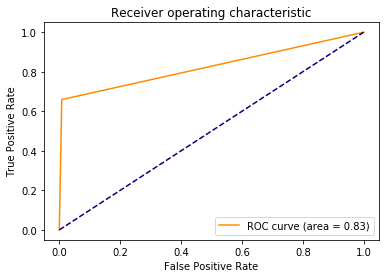

In [44]:
# Calculate area under curve
fpr, tpr, thresholds = roc_curve(yL_test, LR_ypred)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")